In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

In [2]:
minist = tf.keras.datasets.mnist

In [3]:
(X_train , y_train), (X_test, y_test) = minist.load_data()

In [4]:
X_train.shape

(60000, 28, 28)

In [7]:
x_test.shape

(10000, 28, 28)

In [8]:
X_train = tf.keras.utils.normalize(X_train, axis=1)
x_test = tf.keras.utils.normalize(X_test, axis=1)

In [9]:
model = tf.keras.models.Sequential()
model.add(tf.keras.layers.Flatten(input_shape=(28,28)))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(128, activation='relu'))
model.add(tf.keras.layers.Dense(10, activation='linear'))


d:\AI course\Projects\HandWritten Digit Recognition\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [10]:
model.compile(optimizer='adam', loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), metrics=['accuracy'])

In [11]:
model.fit(X_train, y_train, epochs=10)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9243 - loss: 0.2609
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9671 - loss: 0.1073
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9764 - loss: 0.0733
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9829 - loss: 0.0532
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9863 - loss: 0.0425
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9896 - loss: 0.0322
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9916 - loss: 0.0257
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9926 - loss: 0.0216
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.9940 - loss: 0.0176
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 3s 1ms/step - accuracy: 0.9944 - loss: 0.0159


In [12]:
loss , accuracy = model.evaluate(X_test, y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9631 - loss: 87.9810


In [13]:
model.save('handwritten.keras')

In [85]:
model = tf.keras.models.load_model('handwritten.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
The predicted digit is: 9


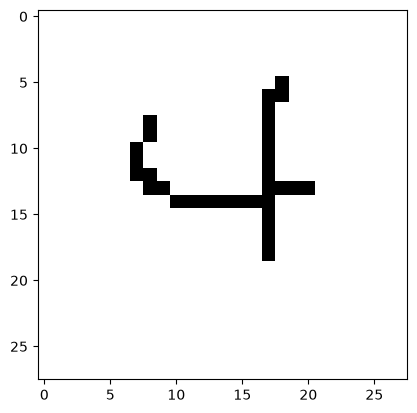

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
The predicted digit is: 9


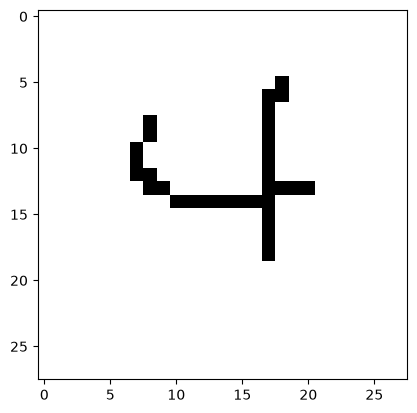

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The predicted digit is: 5


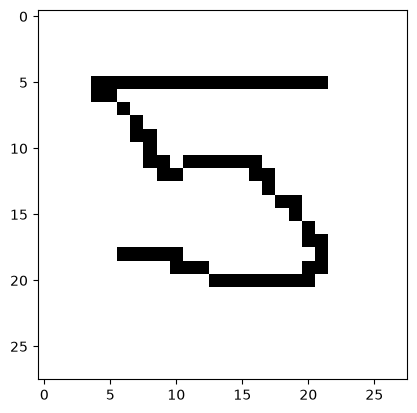

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
The predicted digit is: 7


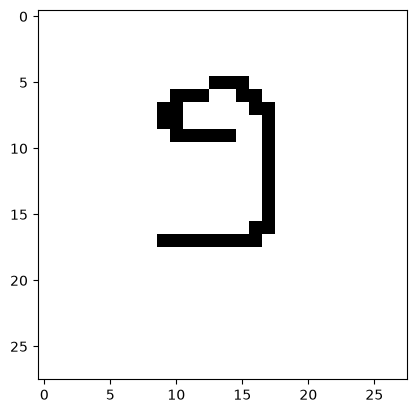

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
The predicted digit is: 9


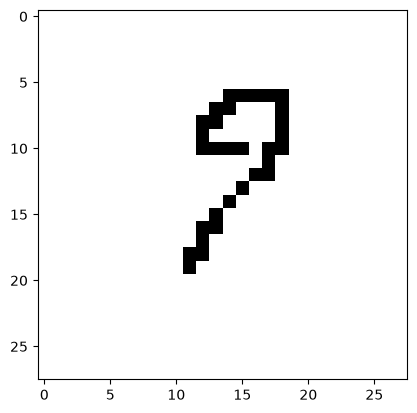

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
The predicted digit is: 1


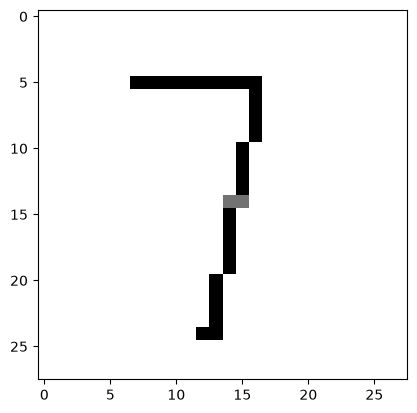

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
The predicted digit is: 7


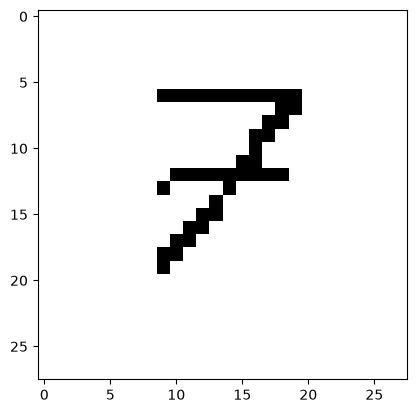

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step
The predicted digit is: 4


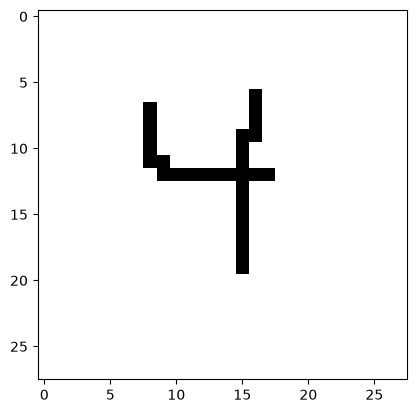

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
The predicted digit is: 9


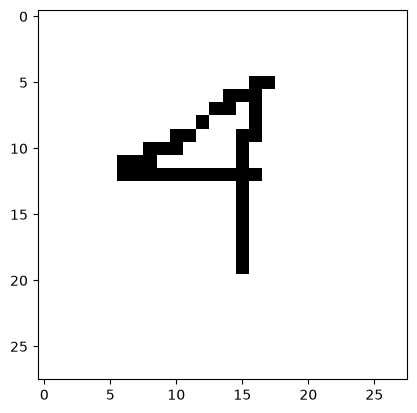

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
The predicted digit is: 8


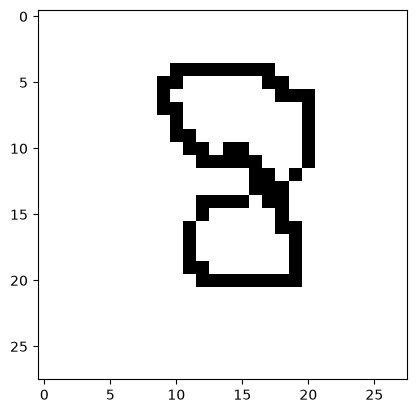

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The predicted digit is: 7


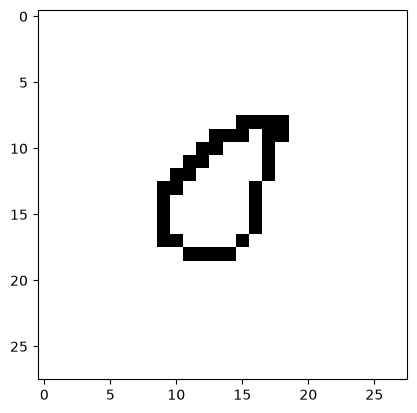

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
The predicted digit is: 1


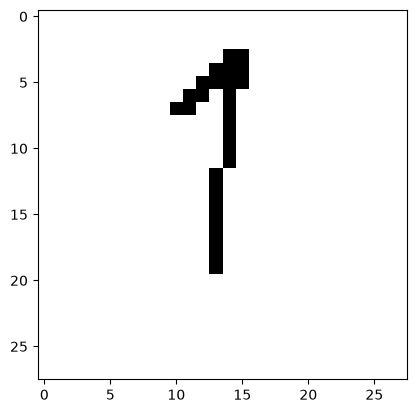

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
The predicted digit is: 7


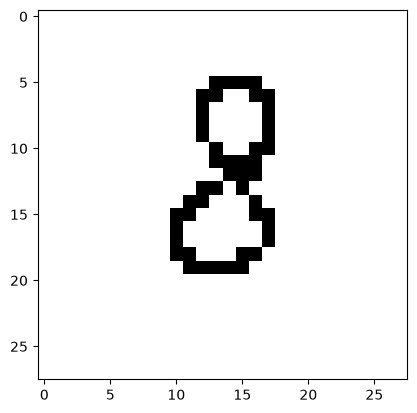

In [92]:
img_num = 1
while os.path.isfile(f"digits/digit{img_num}.png"):
    try:
        img = cv2.imread(f"digits/digit{img_num}.png")[:,:,0]
        img = np.invert(np.array([img]))
        prediction = model.predict(img)
        print(f"The predicted digit is: {np.argmax(prediction)}")
        plt.imshow(img[0], cmap=plt.cm.binary)
        plt.show()
    except:
        print("Error loading image")
    finally:
        img_num += 1
